In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/radshub/data-travel-prices/Data-Travel-Prices.xls


# Airfare Price Prediction & Business Analytics

## Predictive Modeling, Model Selection & Validation

This case study presents an end-to-end business analytics approach to understanding and predicting airline fares using historical route-level data.

The analysis examines numerical and categorical factors associated with airfare, applies stepwise and exhaustive regression techniques for model selection, and evaluates predictive performance using RMSE, average prediction error, and lift analysis.

The results are further translated into business insights through prospective fare estimation, Southwest scenario analysis, and development of a pre-operation pricing model using information available before a route begins.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf

# Load the dataset
file_path = "/kaggle/input/datasets/radshub/data-travel-prices/Data-Travel-Prices.xls"

airfares = pd.read_excel(
    file_path,
    sheet_name="data"
)

print("Dataset shape:", airfares.shape)

Dataset shape: (638, 18)


# 1. Business Problem

Airline ticket prices vary substantially across routes and are influenced by a combination of market characteristics, route distance, competition, airport conditions, passenger demand, and travel patterns.

The objective of this analysis is to use historical airfare data to:

- Identify the key factors associated with airline fares.
- Develop statistical models for predicting airfare.
- Compare different model-selection approaches.
- Validate model performance on unseen data.
- Estimate the expected fare for a prospective route.
- Examine the difference in predicted fare associated with Southwest Airlines (SW).
- Develop a pre-operation pricing model using variables that are available before a new route begins.
- Translate the statistical findings into practical business insights for airline pricing and route planning.

The analysis therefore combines **exploratory data analysis, regression modeling, model selection, predictive validation, and business interpretation**.

# 2. Dataset and Variables

The dataset contains 638 observations and 18 variables describing airline routes, market characteristics, operational conditions, passenger volume, and airfare.

The target variable is **FARE**, representing the airfare for each route.

### Data Quality

- Observations: 638
- Variables: 18
- Missing values: None
- Target variable: FARE

The dataset contains both numerical and categorical variables. Route identifiers and city codes are retained for reference, while the analytical models focus on variables relevant to airfare prediction.

In [30]:
import pandas as pd

file_path = "/kaggle/input/datasets/radshub/data-travel-prices/Data-Travel-Prices.xls"

airfares = pd.read_excel(file_path, sheet_name="data")

airfares.head()

,S_CODE,S_CITY,E_CODE,E_CITY,COUPON,NEW,VACATION,SW,HI,S_INCOME,E_INCOME,S_POP,E_POP,SLOT,GATE,DISTANCE,PAX,FARE
0,*,Dallas/Fort Worth TX,*,Amarillo TX,1.00,3,No,Yes,5291.991341,28637,21112,3036732,205711,Free,Free,312,7864,64.11
1,*,Atlanta GA,*,Baltimore/Wash Intl MD,1.06,3,No,No,5419.160907,26993,29838,3532657,7145897,Free,Free,576,8820,174.47
2,*,Boston MA,*,Baltimore/Wash Intl MD,1.06,3,No,No,9185.283234,30124,29838,5787293,7145897,Free,Free,364,6452,207.76
3,ORD,Chicago IL,*,Baltimore/Wash Intl MD,1.06,3,No,Yes,2657.351987,29260,29838,7830332,7145897,Controlled,Free,612,25144,85.47
4,MDW,Chicago IL,*,Baltimore/Wash Intl MD,1.06,3,No,Yes,2657.351987,29260,29838,7830332,7145897,Free,Free,612,25144,85.47


In [31]:
# Check dataset dimensions
print("Rows and columns:", airfares.shape)

# Check column names
print("\nColumns:")
print(airfares.columns.tolist())

# Check data types and missing values
print("\nData information:")
airfares.info()

print("\nMissing values:")
print(airfares.isnull().sum())

Rows and columns: (638, 18)

Columns:
['S_CODE', 'S_CITY', 'E_CODE', 'E_CITY', 'COUPON', 'NEW', 'VACATION', 'SW', 'HI', 'S_INCOME', 'E_INCOME', 'S_POP', 'E_POP', 'SLOT', 'GATE', 'DISTANCE', 'PAX', 'FARE']

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   S_CODE    638 non-null    object 
 1   S_CITY    638 non-null    object 
 2   E_CODE    638 non-null    object 
 3   E_CITY    638 non-null    object 
 4   COUPON    638 non-null    float64
 5   NEW       638 non-null    int64  
 6   VACATION  638 non-null    object 
 7   SW        638 non-null    object 
 8   HI        638 non-null    float64
 9   S_INCOME  638 non-null    int64  
 10  E_INCOME  638 non-null    int64  
 11  S_POP     638 non-null    int64  
 12  E_POP     638 non-null    int64  
 13  SLOT      638 non-null    object 
 14  GATE      638 non-null    object 
 15  DIS

# 3. Data Preparation

The dataset contains both numerical and categorical variables. For regression modeling, the categorical variables are converted into categorical data types so that they can be appropriately represented as predictors.

The categorical variables used in the analysis are:

- **VACATION** – whether the route is associated with vacation travel
- **SW** – whether Southwest Airlines operates on the route
- **SLOT** – airport slot availability condition
- **GATE** – airport gate availability condition

The route and city identifier variables are retained for reference but are not used as predictors in the regression models.

In [32]:
# Convert categorical variables to category type

categorical_vars = ["VACATION", "SW", "SLOT", "GATE"]

for col in categorical_vars:
    airfares[col] = airfares[col].astype("category")

# Display category levels
for col in categorical_vars:
    print(f"{col}: {airfares[col].cat.categories.tolist()}")

VACATION: ['No', 'Yes']
SW: ['No', 'Yes']
SLOT: ['Controlled', 'Free']
GATE: ['Constrained', 'Free']


# 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the distribution of the target variable, identify important relationships between predictors and airfare, and examine potential differences across route and market characteristics.

The analysis begins by examining descriptive statistics and the distribution of airfare before investigating relationships between individual predictors and **FARE**.

In [33]:
# Descriptive statistics for numerical variables

airfares.describe().T

,count,mean,std,min,25%,50%,75%,max
COUPON,638.0,1.202335e+00,2.038207e-01,1.00000,1.040000e+00,1.150000e+00,1.297500e+00,1.94
NEW,638.0,2.753918e+00,7.604481e-01,0.00000,3.000000e+00,3.000000e+00,3.000000e+00,3.00
HI,638.0,4.442141e+03,1.724267e+03,1230.48384,3.090137e+03,4.208183e+03,5.480573e+03,10000.00
S_INCOME,638.0,2.775986e+04,3.596208e+03,14600.00000,2.470600e+04,2.863700e+04,2.969350e+04,38813.00
E_INCOME,638.0,2.766373e+04,4.611325e+03,14600.00000,2.390300e+04,2.640900e+04,3.198100e+04,38813.00
S_POP,638.0,4.557004e+06,3.010985e+06,29838.00000,1.862106e+06,3.532657e+06,7.830332e+06,9056076.00
E_POP,638.0,3.194503e+06,2.735604e+06,111745.00000,1.228816e+06,2.195215e+06,4.549784e+06,9056076.00
DISTANCE,638.0,9.756536e+02,6.462424e+02,114.00000,4.550000e+02,8.500000e+02,1.306250e+03,2764.00
PAX,638.0,1.278221e+04,1.320223e+04,1504.00000,5.328500e+03,7.792000e+03,1.409050e+04,73892.00
FARE,638.0,1.608767e+02,7.602244e+01,42.47000,1.062900e+02,1.446000e+02,2.093500e+02,402.02


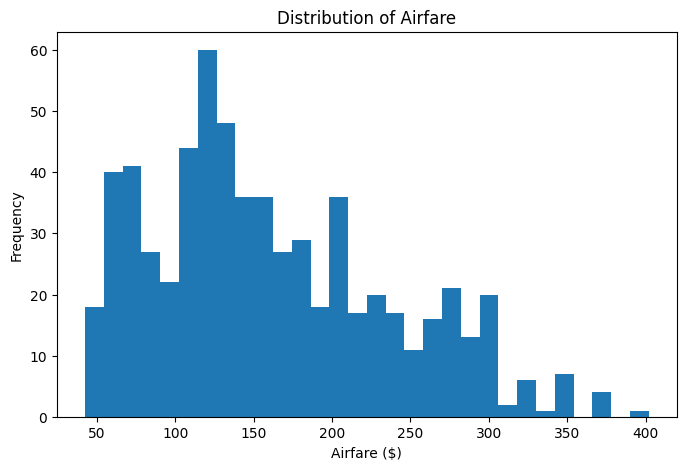

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(airfares["FARE"], bins=30)
plt.xlabel("Airfare ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Airfare")
plt.show()

### Airfare Distribution

The airfare distribution shows the variation in ticket prices across the routes in the dataset. The spread in **FARE** indicates that airline pricing differs substantially across markets, providing a basis for investigating which route, market, and operational characteristics are associated with these differences.

In [35]:
import matplotlib.pyplot as plt

In [36]:
import pandas as pd

file_path = "/kaggle/input/datasets/radshub/data-travel-prices/Data-Travel-Prices.xls"

airfares = pd.read_excel(file_path, sheet_name="data")

print(airfares.shape)
airfares.head()

(638, 18)


,S_CODE,S_CITY,E_CODE,E_CITY,COUPON,NEW,VACATION,SW,HI,S_INCOME,E_INCOME,S_POP,E_POP,SLOT,GATE,DISTANCE,PAX,FARE
0,*,Dallas/Fort Worth TX,*,Amarillo TX,1.00,3,No,Yes,5291.991341,28637,21112,3036732,205711,Free,Free,312,7864,64.11
1,*,Atlanta GA,*,Baltimore/Wash Intl MD,1.06,3,No,No,5419.160907,26993,29838,3532657,7145897,Free,Free,576,8820,174.47
2,*,Boston MA,*,Baltimore/Wash Intl MD,1.06,3,No,No,9185.283234,30124,29838,5787293,7145897,Free,Free,364,6452,207.76
3,ORD,Chicago IL,*,Baltimore/Wash Intl MD,1.06,3,No,Yes,2657.351987,29260,29838,7830332,7145897,Controlled,Free,612,25144,85.47
4,MDW,Chicago IL,*,Baltimore/Wash Intl MD,1.06,3,No,Yes,2657.351987,29260,29838,7830332,7145897,Free,Free,612,25144,85.47


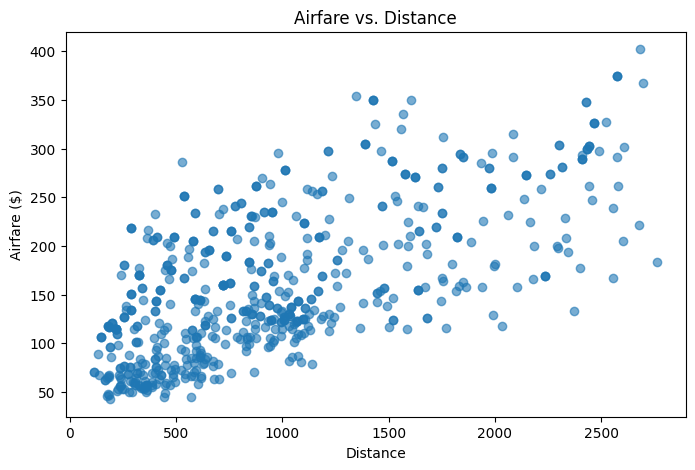

In [37]:
plt.figure(figsize=(8, 5))
plt.scatter(airfares["DISTANCE"], airfares["FARE"], alpha=0.6)
plt.xlabel("Distance")
plt.ylabel("Airfare ($)")
plt.title("Airfare vs. Distance")
plt.show()

### Airfare and Distance

Distance is expected to be an important factor in determining airfare because longer routes generally involve greater operating costs and may be associated with different market conditions.

The scatter plot below examines the relationship between **route distance (`DISTANCE`)** and **airfare (`FARE`)**. The plot shows a clear positive relationship, with airfare generally increasing as route distance increases.

The correlation between `DISTANCE` and `FARE` is approximately **0.670**, indicating a moderately strong positive linear association. Among the numerical predictors examined, distance has the strongest correlation with airfare.

This relationship suggests that **route distance is an important predictor of airfare** and should be considered in subsequent regression models. However, correlation alone does not establish causation, and other market and operational factors may also influence airfare.


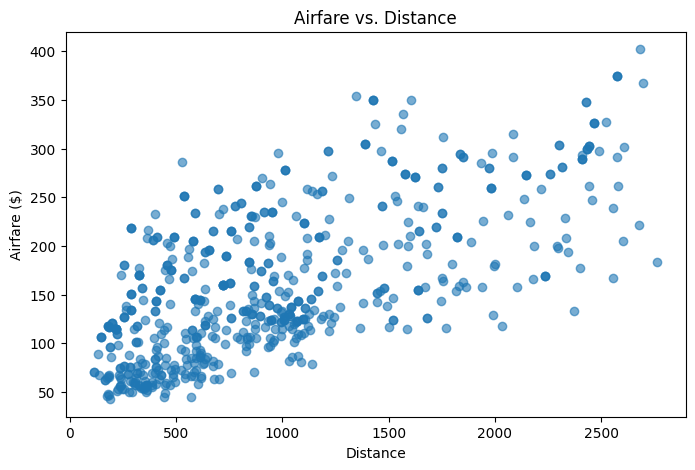

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(airfares["DISTANCE"], airfares["FARE"], alpha=0.6)
plt.xlabel("Distance")
plt.ylabel("Airfare ($)")
plt.title("Airfare vs. Distance")
plt.show()

In [39]:
correlation = airfares["DISTANCE"].corr(airfares["FARE"])
print("Correlation between Distance and Airfare:", correlation)

Correlation between Distance and Airfare: 0.6700159945022622


### Numerical Predictor Correlations

To identify the numerical variables most strongly associated with airfare, correlations were calculated between `FARE` and the available numerical predictors.

The correlation results indicate that **DISTANCE** has the strongest positive association with airfare, with a correlation of approximately **0.670**. `COUPON` is the second strongest numerical predictor, with a correlation of approximately **0.497**.

Other variables such as destination income, destination population, source income, and source population show weaker positive associations with airfare. `PAX` has a small negative correlation with airfare.

Overall, the correlation analysis suggests that **route distance is the most important individual numerical variable associated with airfare**, although multiple factors need to be considered together when building a predictive model.

In [40]:
import numpy as np

In [41]:
numeric_cols = airfares.select_dtypes(include=np.number).columns

correlations = (
    airfares[numeric_cols]
    .corr()["FARE"]
    .drop("FARE")
    .sort_values(key=abs, ascending=False)
)

print(correlations)

DISTANCE    0.670016
COUPON      0.496537
E_INCOME    0.326092
E_POP       0.285043
S_INCOME    0.209135
S_POP       0.145097
NEW         0.091730
PAX        -0.090705
HI          0.025195
Name: FARE, dtype: float64


# Correlation Analysis Interpretation

The correlation analysis shows that `DISTANCE` has the strongest positive relationship with `FARE`, with a correlation of **0.670**. This indicates that longer routes tend to be associated with higher airfares.

`COUPON` is the second strongest numerical variable, with a correlation of approximately **0.497**. `E_INCOME` and `E_POP` also show positive associations, although their relationships with airfare are weaker.

`PAX` has a small negative correlation with airfare (approximately **-0.091`), while `HI` has a very weak relationship with airfare.

Overall, the numerical analysis identifies **DISTANCE as the strongest individual numerical predictor of airfare**. However, these correlations represent associations rather than causal effects, so multiple predictors should be considered simultaneously in the regression models.


### Categorical Predictor Analysis

Categorical variables can capture important market and operational characteristics that may be associated with airfare. Four categorical variables are examined: `VACATION`, `SW`, `SLOT`, and `GATE`.

For each variable, the number and percentage of observations in each category are calculated, along with the average airfare. This provides an initial comparison of airfare across different market conditions.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/kaggle/input/datasets/radshub/data-travel-prices/Data-Travel-Prices.xls"

airfares = pd.read_excel(file_path, sheet_name="data")

print("Dataset shape:", airfares.shape)

Dataset shape: (638, 18)


In [43]:
categorical_vars = ["VACATION", "SW", "SLOT", "GATE"]

for var in categorical_vars:
    summary = airfares.groupby(var)["FARE"].agg(
        Count="count",
        Average_Fare="mean"
    ).reset_index()
    
    summary["Percentage"] = (
        summary["Count"] / len(airfares) * 100
    ).round(1)
    
    print(f"\n{var}")
    print(summary)


VACATION
  VACATION  Count  Average_Fare  Percentage
0       No    468    173.552500        73.4
1      Yes    170    125.980882        26.6

SW
    SW  Count  Average_Fare  Percentage
0   No    444    188.182793        69.6
1  Yes    194     98.382268        30.4

SLOT
         SLOT  Count  Average_Fare  Percentage
0  Controlled    182    186.059396        28.5
1        Free    456    150.825680        71.5

GATE
          GATE  Count  Average_Fare  Percentage
0  Constrained    124    193.129032        19.4
1         Free    514    153.095953        80.6


### Categorical Analysis Interpretation

The categorical analysis shows noticeable differences in average airfare across the different market and operational categories.

For `VACATION`, routes classified as non-vacation routes have an average fare of approximately **$173.55**, compared with **$125.98** for vacation routes.

The largest difference is observed for `SW`. Routes without Southwest Airlines have an average fare of approximately **$188.18**, while routes with Southwest Airlines have an average fare of approximately **$98.38**. This represents an average difference of approximately **$89.80**.

For `SLOT`, routes with controlled slots have an average fare of approximately **$186.06**, compared with **$150.83** for routes with free slots.

For `GATE`, routes with constrained gates have an average fare of approximately **$193.13**, compared with **$153.10** for routes with free gates.

These results indicate that categorical market and operational characteristics are associated with airfare differences. In particular, the large difference associated with `SW` makes Southwest presence an important variable to investigate further in the regression analysis.

However, these are **observational comparisons and should not be interpreted as causal effects**. Other route characteristics may differ systematically between markets with and without Southwest Airlines.

## 5. Data Preparation and Train-Validation Split

Before developing the predictive models, the categorical variables are prepared for use in regression analysis and the dataset is divided into training and validation samples.

A **70% training and 30% validation split** is used. The training dataset is used to estimate the regression models, while the validation dataset is kept separate to evaluate how well the models perform on previously unseen observations.

A fixed random seed is used to make the data split reproducible.


In [44]:
from sklearn.model_selection import train_test_split

# Separate predictors and target
X = airfares.drop(columns=["FARE"])
y = airfares["FARE"]

# 70% training, 30% validation
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123
)

print("Training observations:", len(X_train))
print("Validation observations:", len(X_validation))

Training observations: 446
Validation observations: 192


In [45]:
categorical_vars = ["VACATION", "SW", "SLOT", "GATE"]

for var in categorical_vars:
    print(var, ":", airfares[var].unique())

VACATION : ['No' 'Yes']
SW : ['Yes' 'No']
SLOT : ['Free' 'Controlled']
GATE : ['Free' 'Constrained']


### Categorical Variable Preparation

The dataset contains four categorical predictors: `VACATION`, `SW`, `SLOT`, and `GATE`.

The observed categories are:

* `VACATION`: No, Yes
* `SW`: Yes, No
* `SLOT`: Free, Controlled
* `GATE`: Free, Constrained

These variables represent market, airline, and operational characteristics that may influence airfare. They will be incorporated into the regression models using categorical encoding so that the effect of each category can be estimated relative to a reference category.

In [46]:
# Convert categorical variables to category type
categorical_vars = ["VACATION", "SW", "SLOT", "GATE"]

for var in categorical_vars:
    X_train[var] = X_train[var].astype("category")
    X_validation[var] = X_validation[var].astype("category")

print(X_train.dtypes[categorical_vars])

VACATION    category
SW          category
SLOT        category
GATE        category
dtype: object


### Data Preparation Summary

The dataset was divided into **70% training data (446 observations)** and **30% validation data (192 observations)** using a fixed random seed to ensure reproducibility.

The four categorical variables — `VACATION`, `SW`, `SLOT`, and `GATE` — were converted to categorical data types for use in the regression models.

The training dataset will be used to develop and select predictive models, while the validation dataset will be used to assess **out-of-sample predictive performance**.

## 6. Regression Modeling

### Full Regression Model

A multiple linear regression model is developed to examine the relationship between airfare and multiple numerical and categorical predictors simultaneously.

The full model includes all **13 candidate predictors** identified in the dataset. This provides a baseline model before applying model selection techniques such as stepwise regression and exhaustive subset selection.

The categorical variables are included as categorical predictors, allowing the model to estimate differences between their respective levels.

In [47]:
import statsmodels.formula.api as smf

full_model = smf.ols(
    "FARE ~ COUPON + NEW + C(VACATION) + C(SW) + HI + "
    "S_INCOME + E_INCOME + S_POP + E_POP + "
    "C(SLOT) + C(GATE) + PAX + DISTANCE",
    data=pd.concat([X_train, y_train], axis=1)
).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   FARE   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     116.0
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          8.46e-132
Time:                        10:37:50   Log-Likelihood:                -2233.8
No. Observations:                 446   AIC:                             4496.
Df Residuals:                     432   BIC:                             4553.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             12.3301     33

### Full Regression Model Interpretation

The full multiple linear regression model explains approximately **77.7% of the variation in airfare**, with an adjusted R-squared of **77.1%**.

The overall F-test is statistically significant (`p < 0.001`), indicating that the predictors collectively provide substantial explanatory power for airfare.

Several variables show statistically significant relationships with airfare. `DISTANCE` has a positive coefficient of approximately **0.075**, indicating that longer routes are associated with higher predicted fares, holding the other variables constant. The categorical variables `VACATION`, `SW`, `SLOT`, and `GATE` also show statistically significant differences relative to their reference categories.

`COUPON` is not statistically significant in the full model (`p = 0.441`), while `NEW` is relatively weak (`p = 0.062`). This suggests that some predictors may provide limited additional explanatory value after controlling for the other variables.

The model provides a useful baseline for subsequent model-selection procedures. Stepwise regression will next be used to determine whether a more parsimonious model can provide similar explanatory power with fewer predictors.

### Stepwise Regression Using AIC

Stepwise regression is used to identify a more parsimonious model by removing or adding predictors based on the **Akaike Information Criterion (AIC)**.

The objective is to reduce model complexity while retaining variables that contribute useful explanatory information. The resulting model will be compared with the full model using model fit and validation performance.

In [48]:
# Backward stepwise selection using AIC

data_train = pd.concat([X_train, y_train], axis=1)

predictors = [
    "COUPON",
    "NEW",
    "C(VACATION)",
    "C(SW)",
    "HI",
    "S_INCOME",
    "E_INCOME",
    "S_POP",
    "E_POP",
    "C(SLOT)",
    "C(GATE)",
    "PAX",
    "DISTANCE"
]

current_predictors = predictors.copy()

stepwise_model = smf.ols(
    "FARE ~ " + " + ".join(current_predictors),
    data=data_train
).fit()

while len(current_predictors) > 1:

    candidates = []

    for predictor in current_predictors:
        test_predictors = [
            p for p in current_predictors if p != predictor
        ]

        formula = "FARE ~ " + " + ".join(test_predictors)

        candidate_model = smf.ols(
            formula,
            data=data_train
        ).fit()

        candidates.append(
            (candidate_model.aic, predictor, candidate_model)
        )

    best_aic, removed_predictor, best_model = min(
        candidates,
        key=lambda x: x[0]
    )

    if best_aic < stepwise_model.aic:
        print(
            f"Removing {removed_predictor}: "
            f"AIC {stepwise_model.aic:.2f} -> {best_aic:.2f}"
        )

        current_predictors.remove(removed_predictor)
        stepwise_model = best_model
    else:
        break

print("\nSelected predictors:")
print(current_predictors)

print("\nFinal Stepwise Model:")
print(stepwise_model.summary())

Removing COUPON: AIC 4495.53 -> 4494.14

Selected predictors:
['NEW', 'C(VACATION)', 'C(SW)', 'HI', 'S_INCOME', 'E_INCOME', 'S_POP', 'E_POP', 'C(SLOT)', 'C(GATE)', 'PAX', 'DISTANCE']

Final Stepwise Model:
                            OLS Regression Results                            
Dep. Variable:                   FARE   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     125.7
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          9.91e-133
Time:                        10:37:51   Log-Likelihood:                -2234.1
No. Observations:                 446   AIC:                             4494.
Df Residuals:                     433   BIC:                             4547.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
    

### Stepwise Regression Results

The stepwise regression procedure selected a model containing **12 predictors**, removing only `COUPON` from the original 13-predictor model.

The selected predictors are `NEW`, `VACATION`, `SW`, `HI`, `S_INCOME`, `E_INCOME`, `S_POP`, `E_POP`, `SLOT`, `GATE`, `PAX`, and `DISTANCE`.

The final stepwise model has an **R-squared of 0.777** and an **adjusted R-squared of 0.771**, indicating that the model explains approximately 77.7% of the variation in airfare. The AIC decreased from approximately **4495.53 for the full model to 4494.14** after removing `COUPON`, indicating a slightly more parsimonious model with improved AIC.

`DISTANCE` remains an important positive predictor, with a coefficient of approximately **0.0773**. The categorical variables `VACATION`, `SW`, `SLOT`, and `GATE` also show statistically significant associations with airfare relative to their reference categories.

Overall, the stepwise procedure provides a slightly simpler model without materially reducing explanatory power. This model will subsequently be evaluated on the validation dataset and compared with models identified through exhaustive subset selection.

### Exhaustive Model Selection

To identify a potentially more parsimonious regression model, an exhaustive subset selection procedure is performed.

Unlike stepwise regression, which searches through models sequentially, exhaustive selection evaluates different combinations of the candidate predictors. Models are compared using **Adjusted R-squared, Mallows' Cp, and BIC**.

Adjusted R-squared measures explanatory power while accounting for model size. Mallows' Cp provides a measure of model adequacy relative to the full model, while BIC applies a stronger penalty for unnecessary predictors.

The model selected by BIC will be used as the primary exhaustive-subset model because BIC explicitly balances model fit and complexity.

In [49]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

In [50]:
from sklearn.model_selection import train_test_split

# Recreate predictors and target
X = airfares.drop(columns=["FARE"])
y = airfares["FARE"]

# Recreate the 70/30 split
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123
)

# Convert categorical variables to category type
categorical_vars = ["VACATION", "SW", "SLOT", "GATE"]

for var in categorical_vars:
    X_train[var] = X_train[var].astype("category")
    X_validation[var] = X_validation[var].astype("category")

print("Training observations:", len(X_train))
print("Validation observations:", len(X_validation))

Training observations: 446
Validation observations: 192


In [51]:
from itertools import combinations
import statsmodels.formula.api as smf

data_train = pd.concat([X_train, y_train], axis=1)

predictors = [
    "COUPON",
    "NEW",
    "C(VACATION)",
    "C(SW)",
    "HI",
    "S_INCOME",
    "E_INCOME",
    "S_POP",
    "E_POP",
    "C(SLOT)",
    "C(GATE)",
    "PAX",
    "DISTANCE"
]

results = []

# Fit every possible subset
for k in range(1, len(predictors) + 1):
    for subset in combinations(predictors, k):
        
        formula = "FARE ~ " + " + ".join(subset)
        model = smf.ols(formula, data=data_train).fit()
        
        n = model.nobs
        p = len(subset)
        rss = sum(model.resid ** 2)
        
        # Estimate full-model residual variance
        full_model_rss = sum(full_model.resid ** 2)
        full_df_resid = full_model.df_resid
        mse_full = full_model_rss / full_df_resid
        
        # Mallows' Cp
        cp = rss / mse_full - (n - 2 * (p + 1))
        
        results.append({
            "Num_Predictors": k,
            "Predictors": " + ".join(subset),
            "Adj_R2": model.rsquared_adj,
            "Cp": cp,
            "BIC": model.bic
        })

subset_results = pd.DataFrame(results)

print("Number of models evaluated:", len(subset_results))

Number of models evaluated: 8191


In [52]:
# Find the best model according to each criterion

best_adj_r2 = subset_results.loc[
    subset_results["Adj_R2"].idxmax()
]

best_cp = subset_results.loc[
    subset_results["Cp"].idxmin()
]

best_bic = subset_results.loc[
    subset_results["BIC"].idxmin()
]

print("Best model by Adjusted R-squared:")
print(best_adj_r2)

print("\nBest model by Mallows' Cp:")
print(best_cp)

print("\nBest model by BIC:")
print(best_bic)

Best model by Adjusted R-squared:
Num_Predictors                                                   12
Predictors        NEW + C(VACATION) + C(SW) + HI + S_INCOME + E_...
Adj_R2                                                     0.770807
Cp                                                        12.594631
BIC                                                      4547.44544
Name: 8189, dtype: object

Best model by Mallows' Cp:
Num_Predictors                                                   12
Predictors        NEW + C(VACATION) + C(SW) + HI + S_INCOME + E_...
Adj_R2                                                     0.770807
Cp                                                        12.594631
BIC                                                      4547.44544
Name: 8189, dtype: object

Best model by BIC:
Num_Predictors                                                    9
Predictors        C(VACATION) + C(SW) + HI + S_POP + E_POP + C(S...
Adj_R2                                            

In [53]:
# Create a clean comparison table

model_comparison = pd.DataFrame({
    "Selection Criterion": [
        "Adjusted R-squared",
        "Mallows' Cp",
        "BIC"
    ],
    "Number of Predictors": [
        best_adj_r2["Num_Predictors"],
        best_cp["Num_Predictors"],
        best_bic["Num_Predictors"]
    ],
    "Adjusted R-squared": [
        best_adj_r2["Adj_R2"],
        best_cp["Adj_R2"],
        best_bic["Adj_R2"]
    ],
    "Mallows' Cp": [
        best_adj_r2["Cp"],
        best_cp["Cp"],
        best_bic["Cp"]
    ],
    "BIC": [
        best_adj_r2["BIC"],
        best_cp["BIC"],
        best_bic["BIC"]
    ]
})

model_comparison.round(4)

,Selection Criterion,Number of Predictors,Adjusted R-squared,Mallows' Cp,BIC
0,Adjusted R-squared,12,0.7708,12.5946,4547.4454
1,Mallows' Cp,12,0.7708,12.5946,4547.4454
2,BIC,9,0.7657,19.3069,4542.0618


### Exhaustive Model Selection Results

The exhaustive subset selection evaluated **8,191 possible regression models** using the 13 candidate predictors.

The results show that the model with the highest **Adjusted R-squared** contains **12 predictors**, with an adjusted R-squared of approximately **0.771**. The same 12-predictor model also produces the lowest **Mallows' Cp**, with a value of approximately **12.59**.

In contrast, the **BIC criterion selects a more parsimonious model containing 9 predictors**. This model has an adjusted R-squared of approximately **0.766** and a BIC of approximately **4542.06**. BIC applies a stronger penalty for model complexity, which explains why it selects fewer predictors than the Adjusted R-squared and Cp criteria.

The BIC-selected model includes `VACATION`, `SW`, `HI`, `S_POP`, `E_POP`, `SLOT`, `GATE`, `PAX`, and `DISTANCE`.

For the subsequent analysis, the **9-predictor BIC model** is used as the exhaustive-subset model because it provides a more compact specification while retaining substantial explanatory power.

## 8. Model Validation

A model that performs well on historical training data may not perform equally well on new observations. To assess generalization, the selected models are evaluated using the **30% validation dataset that was not used during model fitting**.

Two models are compared:

1. **Stepwise AIC model** — 12 predictors
2. **BIC-selected model** — 9 predictors

Performance is evaluated using **Root Mean Squared Error (RMSE)** and **Average Prediction Error**. RMSE measures the typical magnitude of prediction errors while giving greater weight to larger errors, while average prediction error indicates whether the model systematically over- or under-predicts fares.

This validation provides a more realistic assessment of how the models may perform when applied to new routes or observations.

### BIC-Selected Regression Model

The exhaustive search identified a **9-predictor model** as the preferred specification under the BIC criterion.

The selected predictors are:

* `VACATION`
* `SW`
* `HI`
* `S_POP`
* `E_POP`
* `SLOT`
* `GATE`
* `PAX`
* `DISTANCE`

This model provides a more compact representation of airfare drivers while retaining substantial explanatory power. The next step is to evaluate its performance on the held-out validation dataset and compare it with the stepwise model.

Model validation is important because strong performance on the training data does not necessarily translate into accurate predictions for new observations.

In [54]:
# Build the BIC-selected 9-predictor model

exhaustive_formula = (
    "FARE ~ C(VACATION) + C(SW) + HI + "
    "S_POP + E_POP + C(SLOT) + C(GATE) + "
    "PAX + DISTANCE"
)

exhaustive_model = smf.ols(
    exhaustive_formula,
    data=data_train
).fit()

print(exhaustive_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   FARE   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     162.6
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          2.62e-133
Time:                        10:39:45   Log-Likelihood:                -2240.5
No. Observations:                 446   AIC:                             4501.
Df Residuals:                     436   BIC:                             4542.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             81.9263     12

In [55]:
# Generate validation predictions

stepwise_pred = stepwise_model.predict(X_validation)
bic_pred = exhaustive_model.predict(X_validation)

# Calculate validation metrics
stepwise_rmse = np.sqrt(np.mean((y_validation - stepwise_pred) ** 2))
bic_rmse = np.sqrt(np.mean((y_validation - bic_pred) ** 2))

stepwise_avg_error = np.mean(stepwise_pred - y_validation)
bic_avg_error = np.mean(bic_pred - y_validation)

validation_results = pd.DataFrame({
    "Model": [
        "Stepwise AIC",
        "BIC-Selected"
    ],
    "RMSE": [
        stepwise_rmse,
        bic_rmse
    ],
    "Average Prediction Error": [
        stepwise_avg_error,
        bic_avg_error
    ]
})

validation_results.round(3)

,Model,RMSE,Average Prediction Error
0,Stepwise AIC,32.529,3.667
1,BIC-Selected,32.817,4.463


### Validation Results

The validation results show that both regression models provide similar predictive performance on previously unseen observations.

The **Stepwise AIC model** achieves an RMSE of **32.529**, compared with **32.817** for the BIC-selected model. The average prediction error is **3.667** for the Stepwise model and **4.463** for the BIC-selected model.

The Stepwise model therefore produces slightly lower prediction error on this validation sample. However, the difference in RMSE is relatively small, while the BIC model uses only **9 predictors compared with 12** for the Stepwise model.

This illustrates a practical modeling trade-off: the Stepwise model provides marginally better predictive accuracy in this validation sample, while the BIC model offers a more compact specification that may be easier to interpret and maintain.

For subsequent business scenario analysis, the **BIC-selected model** is retained because its smaller set of predictors provides a clearer and more practical framework for business interpretation.

### Lift Analysis

To complement RMSE-based validation, a lift analysis is used to examine how effectively the model identifies observations with relatively high actual airfares.

Validation observations are ranked from highest to lowest based on predicted airfare. The cumulative average actual airfare is then compared with the overall average airfare in the validation sample.

A lift value above 1 indicates that the model is concentrating observations with higher-than-average actual fares toward the top of the ranked list. This provides a business-oriented view of model usefulness beyond average prediction accuracy.

In [56]:
# Create lift analysis using the BIC-selected model

lift_data = pd.DataFrame({
    "Actual_Fare": y_validation.values,
    "Predicted_Fare": bic_pred.values
})

# Rank observations by predicted airfare
lift_data = lift_data.sort_values(
    "Predicted_Fare",
    ascending=False
).reset_index(drop=True)

# Calculate cumulative average actual fare
lift_data["Cumulative_Avg_Actual"] = (
    lift_data["Actual_Fare"].expanding().mean()
)

# Overall average actual fare
overall_avg_fare = lift_data["Actual_Fare"].mean()

# Calculate lift
lift_data["Lift"] = (
    lift_data["Cumulative_Avg_Actual"] /
    overall_avg_fare
)

# Percentage of observations
lift_data["Percent_Observed"] = (
    (np.arange(len(lift_data)) + 1) /
    len(lift_data) * 100
)

print("Overall average validation fare:",
      round(overall_avg_fare, 2))

print("\nLift at selected population levels:")

for pct in [10, 20, 30, 50, 100]:
    index = int(len(lift_data) * pct / 100) - 1
    print(
        f"{pct}%: "
        f"Lift = {lift_data.loc[index, 'Lift']:.3f}"
    )

Overall average validation fare: 159.84

Lift at selected population levels:
10%: Lift = 1.810
20%: Lift = 1.637
30%: Lift = 1.532
50%: Lift = 1.347
100%: Lift = 1.000


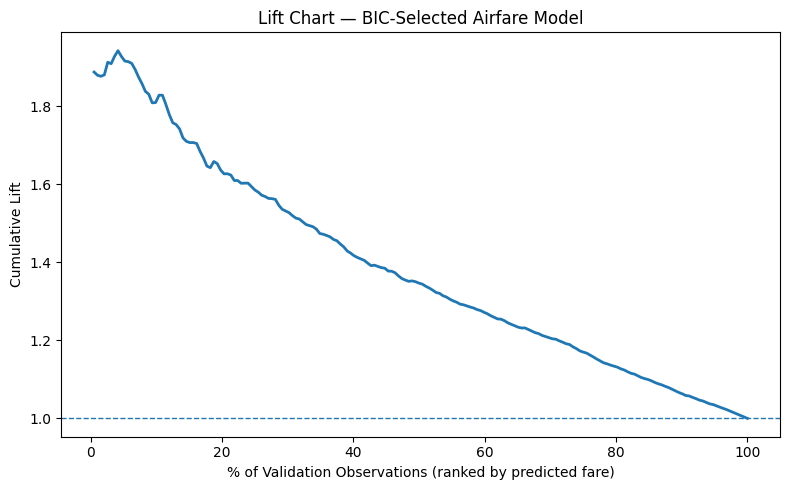

In [57]:
# Plot cumulative lift for the BIC-selected model

plt.figure(figsize=(8, 5))

plt.plot(
    lift_data["Percent_Observed"],
    lift_data["Lift"],
    linewidth=2
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1
)

plt.xlabel("% of Validation Observations (ranked by predicted fare)")
plt.ylabel("Cumulative Lift")
plt.title("Lift Chart — BIC-Selected Airfare Model")

plt.tight_layout()
plt.show()

### Lift Analysis Results

The lift analysis shows that the BIC-selected model effectively ranks higher-fare observations toward the top of the validation sample.

Among the **top 10% of observations ranked by predicted airfare**, the cumulative average actual fare is approximately **1.81 times the overall validation average**. Lift remains above 1.5 through the top 30% of observations and gradually approaches the baseline of 1.0 as the full validation sample is included.

From a business perspective, this indicates that the model is useful not only for estimating individual fares but also for **prioritizing routes or observations where relatively higher fares are expected**. This type of ranking can support targeted pricing reviews, market monitoring, and revenue-management analysis.

Lift analysis complements RMSE by evaluating the model's ability to **identify high-value observations**, rather than measuring only average prediction error.

## 9. Prospective Fare Prediction

After validating the selected model, the next step is to demonstrate how it can be used to estimate airfare for a prospective route.

A hypothetical route profile is created using realistic values for the variables included in the BIC-selected model. The model then generates an estimated airfare for that route.

This demonstrates how a regression model can support practical pricing analysis by translating historical relationships into an estimated fare for a new market scenario.

In [58]:
# Define a hypothetical prospective route

prospective_route = pd.DataFrame({
    "VACATION": pd.Series(["No"], dtype="category"),
    "SW": pd.Series(["No"], dtype="category"),
    "HI": [4442],
    "S_POP": [4_000_000],
    "E_POP": [2_500_000],
    "SLOT": pd.Series(["Free"], dtype="category"),
    "GATE": pd.Series(["Free"], dtype="category"),
    "PAX": [500],
    "DISTANCE": [1_000]
})

# Generate prospective airfare prediction
prospective_fare = exhaustive_model.predict(prospective_route)

print(
    "Estimated prospective airfare: $"
    + f"{prospective_fare.iloc[0]:.2f}"
)

Estimated prospective airfare: $182.24


### Prospective Prediction Result

For the hypothetical route profile defined above, the BIC-selected regression model estimates an airfare of approximately **$182.24**.

This demonstrates how the model can be applied to a new route profile using information available for that market. The estimate should be interpreted as a **model-based benchmark rather than a guaranteed market price**, since actual fares may also reflect competitive conditions, pricing strategy, demand fluctuations, and other factors not captured in the dataset.

The prospective estimate provides a practical starting point for evaluating alternative market scenarios.

In [59]:
# Create an otherwise identical route operated by Southwest

southwest_route = prospective_route.copy()
southwest_route["SW"] = pd.Series(
    ["Yes"],
    dtype="category"
)

# Generate Southwest scenario prediction
southwest_fare = exhaustive_model.predict(southwest_route)

# Calculate the predicted difference
baseline_fare = prospective_fare.iloc[0]
southwest_predicted_fare = southwest_fare.iloc[0]
predicted_difference = southwest_predicted_fare - baseline_fare

print(f"Baseline predicted airfare: ${baseline_fare:.2f}")
print(f"Southwest scenario airfare: ${southwest_predicted_fare:.2f}")
print(f"Predicted difference: ${predicted_difference:.2f}")

Baseline predicted airfare: $182.24
Southwest scenario airfare: $137.95
Predicted difference: $-44.29


### Southwest Scenario Analysis

To examine the potential association between Southwest market presence and airfare, the same prospective route profile was evaluated under two scenarios: `SW = No` and `SW = Yes`.

| Scenario        | Predicted Airfare |
| --------------- | ----------------: |
| Southwest = No  |       **$182.24** |
| Southwest = Yes |       **$137.95** |
| Difference      |       **-$44.29** |

Holding the other route characteristics constant, the model predicts an airfare approximately **$44.29 lower** when the Southwest indicator changes from `No` to `Yes`.

This result is consistent with the negative Southwest coefficient in the regression model and illustrates how the model can be used for **scenario analysis and competitive-market assessment**.

However, this should be interpreted as a **model-adjusted association rather than a causal estimate**. The observational dataset may contain other factors associated with Southwest's presence that are not fully captured by the model. Therefore, the scenario provides a useful analytical benchmark, but it should not be interpreted as evidence that Southwest presence alone causes a $44.29 fare reduction.

In [60]:
# Build a pre-operation model by excluding PAX
# PAX represents passenger volume and may not be available
# when evaluating a route before operations begin.

preop_formula = (
    "FARE ~ C(VACATION) + C(SW) + HI + "
    "S_POP + E_POP + C(SLOT) + C(GATE) + "
    "DISTANCE"
)

preop_model = smf.ols(
    preop_formula,
    data=data_train
).fit()

print(preop_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   FARE   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     173.3
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          2.26e-130
Time:                        10:39:45   Log-Likelihood:                -2250.2
No. Observations:                 446   AIC:                             4518.
Df Residuals:                     437   BIC:                             4555.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             77.6895     12

### Pre-Operation Model Results

The pre-operation model excludes `PAX`, allowing airfare to be estimated using information that can be available before passenger volumes are observed.

The model explains approximately **76.0% of the variation in historical airfare** on the training dataset, with an **Adjusted R² of 75.6%**. The model retains the same core route, market, and operational characteristics used in the BIC-selected model, while removing passenger volume.

Distance remains the strongest continuous predictor in the model, while the Southwest and vacation indicators have negative estimated coefficients. These relationships describe associations within the historical dataset and should not be interpreted as causal effects.

Although removing `PAX` reduces explanatory power compared with the 9-predictor BIC model, the pre-operation model remains a practical framework for **initial route planning and fare benchmarking before passenger demand is known**.

The model will next be evaluated on the held-out validation dataset to determine how much predictive performance is lost when `PAX` is unavailable.

In [61]:
# Validate the pre-operation model on the held-out validation dataset

preop_pred = preop_model.predict(X_validation)

preop_rmse = np.sqrt(
    np.mean((y_validation - preop_pred) ** 2)
)

preop_avg_error = np.mean(
    preop_pred - y_validation
)

print(f"Pre-operation RMSE: {preop_rmse:.3f}")
print(f"Pre-operation Average Prediction Error: {preop_avg_error:.3f}")

# Compare validation performance with the BIC-selected model

print("\nComparison with BIC-selected model:")
print(f"BIC-selected RMSE: {bic_rmse:.3f}")
print(f"Pre-operation RMSE: {preop_rmse:.3f}")
print(f"RMSE increase: {preop_rmse - bic_rmse:.3f}")

Pre-operation RMSE: 33.937
Pre-operation Average Prediction Error: 4.276

Comparison with BIC-selected model:
BIC-selected RMSE: 32.817
Pre-operation RMSE: 33.937
RMSE increase: 1.120


### Pre-Operation Validation Results

The pre-operation model achieves a validation RMSE of **33.937**, compared with **32.817** for the BIC-selected model that includes passenger volume (`PAX`).

Removing `PAX` therefore increases validation RMSE by approximately **1.12 fare units**. The average prediction error is **4.276**, indicating a modest tendency toward over-prediction on this validation sample.

The relatively small increase in RMSE suggests that passenger volume provides additional predictive information, but the model retains substantial predictive performance without it.

From a business perspective, this creates two useful applications:

* **Pre-operation planning:** use the model without `PAX` when estimating fares before passenger volumes are available.
* **In-operation forecasting:** use the BIC-selected model when passenger information becomes available to improve predictive accuracy.

This distinction demonstrates how model design can be aligned with the **timing and availability of business data**, rather than optimizing prediction accuracy alone.

In [62]:
# Generate a prospective fare estimate using only pre-operation information

preop_prospective_fare = preop_model.predict(prospective_route)

print(
    "Pre-operation estimated airfare: $"
    + f"{preop_prospective_fare.iloc[0]:.2f}"
)

print(
    "Difference from BIC-selected estimate: $"
    + f"{preop_prospective_fare.iloc[0] - prospective_fare.iloc[0]:.2f}"
)

Pre-operation estimated airfare: $175.56
Difference from BIC-selected estimate: $-6.68


### Pre-Operation Business Insight

For the same hypothetical route, the pre-operation model estimates an airfare of **$175.56**, compared with **$182.24** from the BIC-selected model that includes passenger volume.

The difference between the two estimates is approximately **$6.68**, while the pre-operation model's validation RMSE is only **1.12** higher than the BIC-selected model.

This suggests that the model can provide a useful **early-stage fare benchmark without requiring passenger-volume information**. Once passenger data becomes available, the fuller BIC-selected model can be used to incorporate that additional information.

The key business takeaway is that predictive modeling can support different decision stages: an initial estimate can be generated using information available before operations, followed by an updated forecast as operational data becomes available.

## 10. Business Insights and Implications

The analysis translates the airfare dataset into several practical business insights.

### 1. Distance is a major airfare driver

Distance has a strong positive relationship with airfare and remains an important predictor across the selected regression models. Longer routes are generally associated with higher predicted fares, making distance an important input for fare benchmarking.

### 2. A compact model can provide strong predictive performance

Exhaustive model selection identified a **9-predictor BIC model** that explains approximately **77% of the variation in airfare on the training data** while using fewer predictors than the Stepwise AIC model.

On the held-out validation sample, the BIC-selected model achieved an RMSE of **32.817**, demonstrating that the more compact model retained strong predictive performance.

### 3. Model ranking provides additional business value

The lift analysis shows that the model can effectively prioritize higher-fare observations. The top **10% of observations ranked by predicted fare** had a cumulative lift of approximately **1.81**, meaning their average actual fare was about 1.81 times the overall validation average.

This type of ranking can support targeted pricing reviews and identification of markets where higher fares are expected.

### 4. Scenario analysis can translate model coefficients into business estimates

For the hypothetical route scenario, the model estimated a baseline fare of $182.24. When the Southwest indicator was changed from No to Yes while holding the other modeled characteristics constant, the predicted fare decreased to $137.95, a difference of $44.29.

This represents a model-adjusted association rather than a causal estimate and should be interpreted accordingly.

### 5. Early-stage forecasting is possible without passenger data

The pre-operation model excludes PAX, allowing fare estimation before passenger volumes are observed. Its validation RMSE was 33.937, only 1.12 higher than the BIC-selected model.

For the hypothetical route, the pre-operation model estimated $175.56, compared with $182.24 from the fuller model.

This demonstrates how analytics can support decisions at different stages of the business process: initial planning before operations begin and updated forecasting once operational information becomes available.

### Overall Business Implication

The analysis demonstrates an end-to-end approach to converting historical airfare data into predictive benchmarks, market scenarios, prioritization insights, and early-stage planning estimates. The results also highlight the importance of balancing predictive accuracy, model simplicity, data availability, and appropriate interpretation when developing analytics solutions for business use.

## 11. Limitations and Next Steps

While the analysis provides useful predictive and business insights, several limitations should be considered before applying the results to operational pricing decisions.

### Limitations

* **Historical dataset:** The model is based on historical route-level observations and may not fully represent current market conditions.
* **Observational relationships:** Regression coefficients describe associations within the dataset and should not automatically be interpreted as causal effects.
* **Limited business variables:** Factors such as competitor pricing, seasonality, booking timing, fuel costs, and broader market conditions are not explicitly modeled.
* **Validation sample:** Model performance is evaluated using a single 30% holdout sample. Additional validation across different time periods or markets would provide stronger evidence of generalization.
* **Model assumptions:** Linear regression may not capture nonlinear relationships or interactions between route characteristics and market conditions.

### Recommended Next Steps

For a production-oriented pricing analytics solution, the analysis could be extended by:

1. Incorporating **time-based data** to capture seasonality and market changes.
2. Adding **competitive pricing and market-share information**.
3. Testing nonlinear and machine-learning models such as Random Forest or Gradient Boosting.
4. Using **cross-validation or time-based validation** for more robust performance measurement.
5. Developing automated monitoring to track **prediction accuracy and model drift** after deployment.
6. Separating predictive analysis from causal analysis when evaluating the effect of specific airline or market interventions.

These extensions would help move the analysis from a historical modeling exercise toward a more robust **decision-support and pricing analytics framework**.

## 12. Conclusion

This project demonstrates an end-to-end business analytics workflow for airfare prediction, from exploratory analysis and statistical modeling through model selection, validation, scenario analysis, and business interpretation.

The analysis identified a compact regression model that explains a substantial portion of historical airfare variation while maintaining competitive predictive performance on held-out data. Lift analysis further demonstrated the model's ability to prioritize higher-fare observations, while prospective and pre-operation scenarios showed how the model could support fare benchmarking at different stages of the business process.

The project highlights a core Business Analyst capability: **translating analytical results into practical business insights while clearly communicating assumptions, limitations, and appropriate use of the analysis.**


In [63]:
# Create a portfolio-ready model comparison table

portfolio_model_comparison = pd.DataFrame({
    "Model": [
        "Stepwise AIC",
        "BIC-Selected",
        "Pre-Operation"
    ],
    "Predictors": [
        12,
        9,
        8
    ],
    "Validation_RMSE": [
        stepwise_rmse,
        bic_rmse,
        preop_rmse
    ],
    "Average_Prediction_Error": [
        stepwise_avg_error,
        bic_avg_error,
        preop_avg_error
    ]
})

portfolio_model_comparison.round(3)

,Model,Predictors,Validation_RMSE,Average_Prediction_Error
0,Stepwise AIC,12,32.529,3.667
1,BIC-Selected,9,32.817,4.463
2,Pre-Operation,8,33.937,4.276


In [64]:
# Export model comparison results for the portfolio

portfolio_model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Saved: model_comparison.csv")

Saved: model_comparison.csv


In [65]:
# Create portfolio-ready prospective scenario results

scenario_results = pd.DataFrame({
    "Scenario": [
        "Baseline Prospective Route",
        "Southwest Scenario",
        "Pre-Operation Model"
    ],
    "Predicted_Fare": [
        prospective_fare.iloc[0],
        southwest_predicted_fare,
        preop_prospective_fare.iloc[0]
    ]
})

scenario_results["Difference_vs_Baseline"] = (
    scenario_results["Predicted_Fare"]
    - prospective_fare.iloc[0]
)

scenario_results.round(2)

,Scenario,Predicted_Fare,Difference_vs_Baseline
0,Baseline Prospective Route,182.24,0.00
1,Southwest Scenario,137.95,-44.29
2,Pre-Operation Model,175.56,-6.68


In [66]:
# Export prospective scenario results for the portfolio

scenario_results.to_csv(
    "predictions.csv",
    index=False
)

print("Saved: predictions.csv")

Saved: predictions.csv


In [67]:
# Export lift analysis results for the portfolio

lift_data.to_csv(
    "lift_analysis.csv",
    index=False
)

print("Saved: lift_analysis.csv")

Saved: lift_analysis.csv


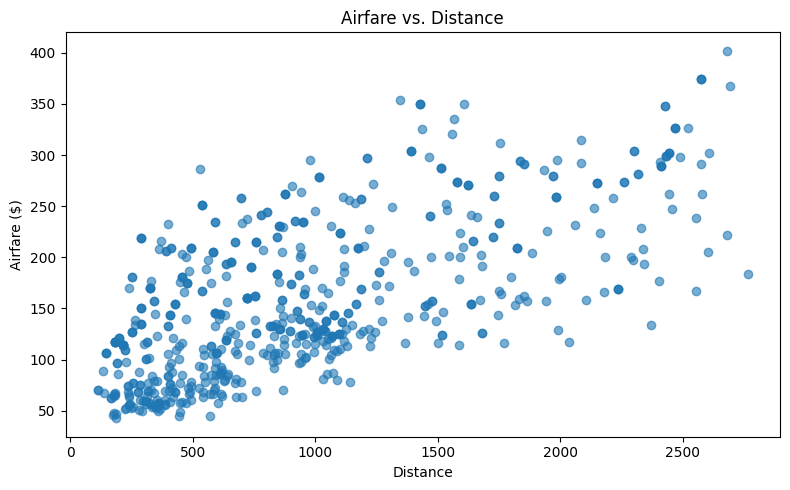

Saved: fare_distance.png


In [68]:
# Save Airfare vs. Distance figure

plt.figure(figsize=(8, 5))

plt.scatter(
    airfares["DISTANCE"],
    airfares["FARE"],
    alpha=0.6
)

plt.xlabel("Distance")
plt.ylabel("Airfare ($)")
plt.title("Airfare vs. Distance")

plt.tight_layout()

plt.savefig(
    "fare_distance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: fare_distance.png")

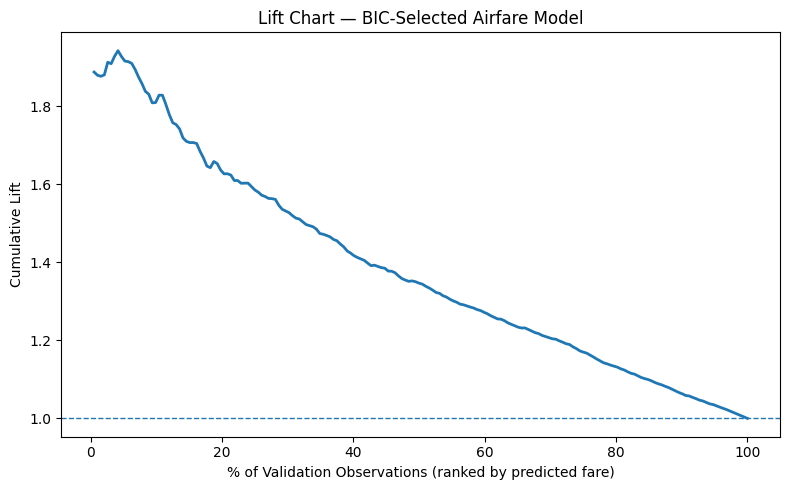

Saved: lift_chart.png


In [69]:
# Save Lift Chart

plt.figure(figsize=(8, 5))

plt.plot(
    lift_data["Percent_Observed"],
    lift_data["Lift"],
    linewidth=2
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1
)

plt.xlabel("% of Validation Observations (ranked by predicted fare)")
plt.ylabel("Cumulative Lift")
plt.title("Lift Chart — BIC-Selected Airfare Model")

plt.tight_layout()

plt.savefig(
    "lift_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: lift_chart.png")

In [70]:
# Create a portfolio-ready project summary

project_summary = pd.DataFrame({
    "Metric": [
        "Training Observations",
        "Validation Observations",
        "BIC-Selected Predictors",
        "BIC-Selected Training Adjusted R2",
        "BIC-Selected Validation RMSE",
        "Top 10% Lift",
        "Baseline Prospective Fare",
        "Southwest Scenario Fare",
        "Southwest Scenario Difference",
        "Pre-Operation Validation RMSE",
        "Pre-Operation Prospective Fare"
    ],
    "Value": [
        len(X_train),
        len(X_validation),
        9,
        exhaustive_model.rsquared_adj,
        bic_rmse,
        lift_data.loc[
            int(len(lift_data) * 0.10) - 1,
            "Lift"
        ],
        prospective_fare.iloc[0],
        southwest_predicted_fare,
        predicted_difference,
        preop_rmse,
        preop_prospective_fare.iloc[0]
    ]
})

project_summary.round(3)

,Metric,Value
0,Training Observations,446.000
1,Validation Observations,192.000
2,BIC-Selected Predictors,9.000
3,BIC-Selected Training Adjusted R2,0.766
4,BIC-Selected Validation RMSE,32.817
5,Top 10% Lift,1.810
6,Baseline Prospective Fare,182.237
7,Southwest Scenario Fare,137.951
8,Southwest Scenario Difference,-44.286
9,Pre-Operation Validation RMSE,33.937


In [71]:
# Export project summary for the portfolio

project_summary.to_csv(
    "project_summary.csv",
    index=False
)

print("Saved: project_summary.csv")

Saved: project_summary.csv
